In [21]:
import numpy as np
import pandas as pd
import re
import spacy
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('all')

import logging
logging.basicConfig(level=logging.INFO)

pd.options.mode.chained_assignment = None

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

In [22]:
!pip install --upgrade malaya
!pip install malaya-speech

In [23]:
%%time
import malaya


CPU times: user 6 µs, sys: 0 ns, total: 6 µs
Wall time: 8.82 µs


In [24]:
!pip install --upgrade malaya
!pip install malaya-speech

In [25]:
file = pd.read_excel('Facebook.xlsx')
df = file[["hashtag", "user/id", "user/name", "likesCount", "sharesCount", "commentsCount", "date", "text"]]
df["text"] = df["text"].astype(str)
df.index = df.index + 1
file.index = file.index + 1
file.head()

,hashtag,user/id,user/name,user/profilePic,user/profileUrl,text,likesCount,sharesCount,commentsCount,date,url
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,https://scontent-hou1-1.xx.fbcdn.net/v/t39.308...,https://www.facebook.com/Leticia.Sink07,Orang #Bodoh \nFitri CHibounda Juan,19,0,4,2023-07-05T01:32:05.000Z,https://www.facebook.com/Leticia.Sink07/posts/...
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,https://scontent-hou1-1.xx.fbcdn.net/v/t39.308...,https://www.facebook.com/people/Komeng-Finaria...,"""#Kesalahan orang-orang #pandai ialah mengangg...",2,4,0,2023-07-05T12:12:14.000Z,https://www.facebook.com/groups/16648670671245...
3,bodoh,100033192617602,Wong N Deso,https://scontent-hou1-1.xx.fbcdn.net/v/t39.308...,https://www.facebook.com/people/Wong-N-Deso/10...,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...,75,0,92,2023-05-31T10:55:44.000Z,https://www.facebook.com/groups/24835887752521...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,https://scontent-hou1-1.xx.fbcdn.net/v/t1.6435...,https://www.facebook.com/suyati.suyati.14606936,Heran kenapa si Endrow mau aja ma Namirot stlh...,50,1,22,2023-06-23T23:04:19.000Z,https://www.facebook.com/groups/59627472470923...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,https://scontent-hou1-1.xx.fbcdn.net/v/t39.308...,https://www.facebook.com/ahlian.property,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...,0,0,0,2023-07-08T06:16:47.000Z,https://www.facebook.com/ahlian.property/posts...


In [26]:
df.head()

,hashtag,user/id,user/name,likesCount,sharesCount,commentsCount,date,text
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,19,0,4,2023-07-05T01:32:05.000Z,Orang #Bodoh \nFitri CHibounda Juan
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,2,4,0,2023-07-05T12:12:14.000Z,"""#Kesalahan orang-orang #pandai ialah mengangg..."
3,bodoh,100033192617602,Wong N Deso,75,0,92,2023-05-31T10:55:44.000Z,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,50,1,22,2023-06-23T23:04:19.000Z,Heran kenapa si Endrow mau aja ma Namirot stlh...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,0,0,0,2023-07-08T06:16:47.000Z,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...


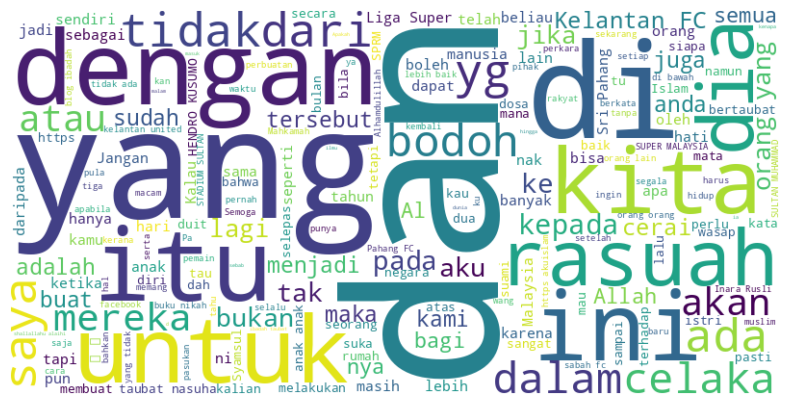

In [27]:
from wordcloud import WordCloud
data = pd.read_excel('Facebook.xlsx')
text_data = data["text"].dropna().str.cat(sep=' ')

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
plt.figure(figsize=(10, 5))  # Adjust the figure size (optional)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.show()
wordcloud.to_file("wordcloud_facebook_raw.png")

Data Preprocessing

In [28]:
# check missing value
file.isnull().sum()

,0
hashtag,0
user/id,0
user/name,0
user/profilePic,0
user/profileUrl,64
text,35
likesCount,0
sharesCount,0
commentsCount,0
date,0


In [29]:
df["text_lower"] = df["text"].str.lower()
df.head()

,hashtag,user/id,user/name,likesCount,sharesCount,commentsCount,date,text,text_lower
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,19,0,4,2023-07-05T01:32:05.000Z,Orang #Bodoh \nFitri CHibounda Juan,orang #bodoh \nfitri chibounda juan
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,2,4,0,2023-07-05T12:12:14.000Z,"""#Kesalahan orang-orang #pandai ialah mengangg...","""#kesalahan orang-orang #pandai ialah mengangg..."
3,bodoh,100033192617602,Wong N Deso,75,0,92,2023-05-31T10:55:44.000Z,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,50,1,22,2023-06-23T23:04:19.000Z,Heran kenapa si Endrow mau aja ma Namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,0,0,0,2023-07-08T06:16:47.000Z,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...,# sangat developer ni 【 】 kondo ❌rm700k ✅hanya...


Remove punctuation

In [30]:
PUNCT_TO_REMOVE = string.punctuation

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

df["text_wo_punct"] = df["text_lower"].apply(lambda text: remove_punctuation(text))
df.head()

,hashtag,user/id,user/name,likesCount,sharesCount,commentsCount,date,text,text_lower,text_wo_punct
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,19,0,4,2023-07-05T01:32:05.000Z,Orang #Bodoh \nFitri CHibounda Juan,orang #bodoh \nfitri chibounda juan,orang bodoh \nfitri chibounda juan
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,2,4,0,2023-07-05T12:12:14.000Z,"""#Kesalahan orang-orang #pandai ialah mengangg...","""#kesalahan orang-orang #pandai ialah mengangg...",kesalahan orangorang pandai ialah menganggap y...
3,bodoh,100033192617602,Wong N Deso,75,0,92,2023-05-31T10:55:44.000Z,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,50,1,22,2023-06-23T23:04:19.000Z,Heran kenapa si Endrow mau aja ma Namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,0,0,0,2023-07-08T06:16:47.000Z,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...,# sangat developer ni 【 】 kondo ❌rm700k ✅hanya...,sangat developer ni 【 】 kondo ❌rm700k ✅hanya ...


In [31]:
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Define your list of stopwords
stopwords_list = ['ada', 'inikah', 'sampai', 'adakah', 'inilah', 'sana', 'adakan', 'itu', 'sangat', 'adalah',
    'itukah', 'sangatlah', 'adanya', 'itulah', 'saya', 'adapun', 'jadi', 'se', 'agak', 'jangan',
    'seandainya', 'agar', 'janganlah', 'sebab', 'akan', 'jika', 'sebagai', 'aku', 'jikalau',
    'sebagaimana', 'akulah', 'jua', 'sebanyak', 'akupun', 'juapun', 'sebelum', 'al', 'juga',
    'sebelummu', 'alangkah', 'kalau', 'sebelumnya', 'allah', 'kami', 'sebenarnya', 'amat',
    'kamikah', 'secara', 'antara', 'kamipun', 'sedang', 'antaramu', 'kamu', 'sedangkan',
    'antaranya', 'kamukah', 'sedikit', 'apa', 'kamupun', 'sedikitpun', 'apa-apa', 'katakan',
    'segala', 'apabila', 'ke', 'sehingga', 'apakah', 'kecuali', 'sejak', 'apapun', 'kelak',
    'sekalian', 'atas', 'kembali', 'sekalipun', 'atasmu', 'kemudian', 'sekarang', 'atasnya',
    'kepada', 'sekitar', 'atau', 'kepadaku', 'selain', 'ataukah', 'kepadakulah', 'selalu',
    'ataupun', 'kepadamu', 'selama', 'bagaimana', 'kepadanya', 'selama-lamanya', 'bagaimanakah',
    'kepadanyalah', 'seluruh', 'bagi', 'kerana', 'seluruhnya', 'bagimu', 'kerananya', 'sementara',
    'baginya', 'kesan', 'semua', 'bahawa', 'ketika', 'semuanya', 'bahawasanya', 'kini',
    'semula', 'bahkan', 'kita', 'senantiasa', 'bahwa', 'ku', 'sendiri', 'banyak', 'kurang',
    'sentiasa', 'banyaknya', 'lagi', 'seolah', 'barangsiapa', 'lain', 'seolah-olah', 'bawah',
    'lalu', 'seorangpun', 'beberapa', 'lamanya', 'separuh', 'begitu', 'langsung', 'sepatutnya',
    'begitupun', 'lebih', 'seperti', 'belaka', 'maha', 'seraya', 'belum', 'mahu', 'sering',
    'belumkah', 'mahukah', 'serta', 'berada', 'mahupun', 'seseorang', 'berapa', 'maka',
    'sesiapa', 'berikan', 'malah', 'sesuatu', 'beriman', 'mana', 'sesudah', 'berkenaan',
    'manakah', 'sesudahnya', 'berupa', 'manapun', 'sesungguhnya', 'beserta', 'masih',
    'sesungguhnyakah', 'biarpun', 'masing', 'setelah', 'bila', 'masing-masing', 'setiap',
    'bilakah', 'melainkan', 'siapa', 'bilamana', 'memang', 'siapakah', 'bisa', 'mempunyai',
    'sini', 'boleh', 'mendapat', 'situ', 'bukan', 'mendapati', 'situlah', 'bukankah',
    'mendapatkan', 'suatu', 'bukanlah', 'mengadakan', 'sudah', 'dahulu', 'mengapa', 'sudahkah',
    'dalam', 'mengapakah', 'sungguh', 'dalamnya', 'mengenai', 'sungguhpun', 'dan', 'menjadi',
    'supaya', 'dapat', 'menyebabkan', 'tadinya', 'dapati', 'menyebabkannya', 'tahukah',
    'dapatkah', 'mereka', 'tak', 'dapatlah', 'merekalah', 'tanpa', 'dari', 'merekapun',
    'tanya', 'daripada', 'meskipun', 'tanyakanlah', 'daripadaku', 'mu', 'tapi', 'daripadamu',
    'nescaya', 'telah', 'daripadanya', 'niscaya', 'tentang', 'demi', 'nya', 'tentu', 'demikian',
    'olah', 'terdapat', 'demikianlah', 'oleh', 'terhadap', 'dengan', 'orang', 'terhadapmu',
    'dengannya', 'pada', 'termasuk', 'di', 'padahal', 'terpaksa', 'dia', 'padamu', 'tertentu',
    'dialah', 'padanya', 'tetapi', 'didapat', 'paling', 'tiada', 'didapati', 'para',
    'tiadakah', 'dimanakah', 'pasti', 'tiadalah', 'engkau', 'patut', 'tiap', 'engkaukah',
    'patutkah', 'tiap-tiap', 'engkaulah', 'per', 'tidak', 'engkaupun', 'pergilah', 'tidakkah',
    'hai', 'perkara', 'tidaklah', 'hampir', 'perkaranya', 'turut', 'hampir-hampir', 'perlu',
    'untuk', 'hanya', 'pernah', 'untukmu', 'hanyalah', 'pertama', 'wahai', 'hendak', 'pula',
    'walau', 'hendaklah', 'pun', 'walaupun', 'hingga', 'sahaja', 'ya', 'ia', 'saja', 'yaini',
    'iaitu', 'saling', 'yaitu', 'ianya', 'sama', 'yakni', 'ianya', 'sama-sama', 'yang',
    'inginkah', 'samakah', 'ini', 'sambil']

# Function to remove stopwords from a given text
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stopwords_list]
    return ' '.join(filtered_words)

# Apply the remove_stopwords function to the 'text' column and create a new 'text_wo_stop' column
df['text_wo_stop'] = df["text_wo_punct"].apply(remove_stopwords)
df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,hashtag,user/id,user/name,likesCount,sharesCount,commentsCount,date,text,text_lower,text_wo_punct,text_wo_stop
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,19,0,4,2023-07-05T01:32:05.000Z,Orang #Bodoh \nFitri CHibounda Juan,orang #bodoh \nfitri chibounda juan,orang bodoh \nfitri chibounda juan,bodoh fitri chibounda juan
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,2,4,0,2023-07-05T12:12:14.000Z,"""#Kesalahan orang-orang #pandai ialah mengangg...","""#kesalahan orang-orang #pandai ialah mengangg...",kesalahan orangorang pandai ialah menganggap y...,kesalahan orangorang pandai ialah menganggap y...
3,bodoh,100033192617602,Wong N Deso,75,0,92,2023-05-31T10:55:44.000Z,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...,izin atmin klarifikasi mhd fredy bru ngerti so...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,50,1,22,2023-06-23T23:04:19.000Z,Heran kenapa si Endrow mau aja ma Namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,0,0,0,2023-07-08T06:16:47.000Z,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...,# sangat developer ni 【 】 kondo ❌rm700k ✅hanya...,sangat developer ni 【 】 kondo ❌rm700k ✅hanya ...,developer ni 【 】 kondo ❌rm700k ✅hanya jual【】 l...


In [32]:
from collections import Counter
cnt = Counter()
for text in df["text_wo_stop"].values:
    for word in text.split():
        cnt[word] += 1

cnt.most_common(10)

[('yg', 264),
 ('rasuah', 240),
 ('kelantan', 204),
 ('fc', 197),
 ('bodoh', 183),
 ('cerai', 151),
 ('anak', 149),
 ('tersebut', 136),
 ('celaka', 134),
 ('malaysia', 123)]

In [33]:
FREQWORDS = set([w for (w, wc) in cnt.most_common(10)])
def remove_freqwords(text):
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

df["text_wo_stopfreq"] = df["text_wo_stop"].apply(lambda text: remove_freqwords(text))
df.head()

,hashtag,user/id,user/name,likesCount,sharesCount,commentsCount,date,text,text_lower,text_wo_punct,text_wo_stop,text_wo_stopfreq
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,19,0,4,2023-07-05T01:32:05.000Z,Orang #Bodoh \nFitri CHibounda Juan,orang #bodoh \nfitri chibounda juan,orang bodoh \nfitri chibounda juan,bodoh fitri chibounda juan,fitri chibounda juan
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,2,4,0,2023-07-05T12:12:14.000Z,"""#Kesalahan orang-orang #pandai ialah mengangg...","""#kesalahan orang-orang #pandai ialah mengangg...",kesalahan orangorang pandai ialah menganggap y...,kesalahan orangorang pandai ialah menganggap y...,kesalahan orangorang pandai ialah menganggap b...
3,bodoh,100033192617602,Wong N Deso,75,0,92,2023-05-31T10:55:44.000Z,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,50,1,22,2023-06-23T23:04:19.000Z,Heran kenapa si Endrow mau aja ma Namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,0,0,0,2023-07-08T06:16:47.000Z,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...,# sangat developer ni 【 】 kondo ❌rm700k ✅hanya...,sangat developer ni 【 】 kondo ❌rm700k ✅hanya ...,developer ni 【 】 kondo ❌rm700k ✅hanya jual【】 l...,developer ni 【 】 kondo ❌rm700k ✅hanya jual【】 l...


In [34]:
df.drop(["text_wo_punct", "text_wo_stop"], axis=1, inplace=True) # Drop unnecessary columns
n_rare_words = 10
RAREWORDS = set([w for (w, wc) in cnt.most_common()[:-n_rare_words-1:-1]])

def remove_rarewords(text):
    return " ".join([word for word in str(text).split() if word not in RAREWORDS])

df["text_wo_stopfreqrare"] = df["text_wo_stopfreq"].apply(lambda text: remove_rarewords(text))
df.head()

,hashtag,user/id,user/name,likesCount,sharesCount,commentsCount,date,text,text_lower,text_wo_stopfreq,text_wo_stopfreqrare
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,19,0,4,2023-07-05T01:32:05.000Z,Orang #Bodoh \nFitri CHibounda Juan,orang #bodoh \nfitri chibounda juan,fitri chibounda juan,fitri chibounda juan
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,2,4,0,2023-07-05T12:12:14.000Z,"""#Kesalahan orang-orang #pandai ialah mengangg...","""#kesalahan orang-orang #pandai ialah mengangg...",kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...
3,bodoh,100033192617602,Wong N Deso,75,0,92,2023-05-31T10:55:44.000Z,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,50,1,22,2023-06-23T23:04:19.000Z,Heran kenapa si Endrow mau aja ma Namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,0,0,0,2023-07-08T06:16:47.000Z,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...,# sangat developer ni 【 】 kondo ❌rm700k ✅hanya...,developer ni 【 】 kondo ❌rm700k ✅hanya jual【】 l...,developer ni 【 】 kondo ❌rm700k ✅hanya jual【】 l...


In [35]:
df.drop(["text_wo_stopfreq"], axis=1, inplace=True)# Drop unnecessary columns

# Reference : https://gist.github.com/slowkow/7a7f61f495e3dbb7e3d767f97bd7304b
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

df["text_remove_emoji"] = df["text_wo_stopfreqrare"].apply(lambda text: remove_emoji(text))
df.head()


,hashtag,user/id,user/name,likesCount,sharesCount,commentsCount,date,text,text_lower,text_wo_stopfreqrare,text_remove_emoji
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,19,0,4,2023-07-05T01:32:05.000Z,Orang #Bodoh \nFitri CHibounda Juan,orang #bodoh \nfitri chibounda juan,fitri chibounda juan,fitri chibounda juan
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,2,4,0,2023-07-05T12:12:14.000Z,"""#Kesalahan orang-orang #pandai ialah mengangg...","""#kesalahan orang-orang #pandai ialah mengangg...",kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...
3,bodoh,100033192617602,Wong N Deso,75,0,92,2023-05-31T10:55:44.000Z,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,50,1,22,2023-06-23T23:04:19.000Z,Heran kenapa si Endrow mau aja ma Namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,0,0,0,2023-07-08T06:16:47.000Z,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...,# sangat developer ni 【 】 kondo ❌rm700k ✅hanya...,developer ni 【 】 kondo ❌rm700k ✅hanya jual【】 l...,developer ni kondo rm700k hanya jual lokasi ...


In [36]:
# Thanks : https://github.com/NeelShah18/emot/blob/master/emot/emo_unicode.py
EMOTICONS = {
    u":‑\)":"Happy face or smiley",
    u":\)":"Happy face or smiley",
    u":-\]":"Happy face or smiley",
    u":\]":"Happy face or smiley",
    u":-3":"Happy face smiley",
    u":3":"Happy face smiley",
    u":->":"Happy face smiley",
    u":>":"Happy face smiley",
    u"8-\)":"Happy face smiley",
    u":o\)":"Happy face smiley",
    u":-\}":"Happy face smiley",
    u":\}":"Happy face smiley",
    u":-\)":"Happy face smiley",
    u":c\)":"Happy face smiley",
    u":\^\)":"Happy face smiley",
    u"=\]":"Happy face smiley",
    u"=\)":"Happy face smiley",
    u":‑D":"Laughing, big grin or laugh with glasses",
    u":D":"Laughing, big grin or laugh with glasses",
    u"8‑D":"Laughing, big grin or laugh with glasses",
    u"8D":"Laughing, big grin or laugh with glasses",
    u"X‑D":"Laughing, big grin or laugh with glasses",
    u"XD":"Laughing, big grin or laugh with glasses",
    u"=D":"Laughing, big grin or laugh with glasses",
    u"=3":"Laughing, big grin or laugh with glasses",
    u"B\^D":"Laughing, big grin or laugh with glasses",
    u":-\)\)":"Very happy",
    u":‑\(":"Frown, sad, andry or pouting",
    u":-\(":"Frown, sad, andry or pouting",
    u":\(":"Frown, sad, andry or pouting",
    u":‑c":"Frown, sad, andry or pouting",
    u":c":"Frown, sad, andry or pouting",
    u":‑<":"Frown, sad, andry or pouting",
    u":<":"Frown, sad, andry or pouting",
    u":‑\[":"Frown, sad, andry or pouting",
    u":\[":"Frown, sad, andry or pouting",
    u":-\|\|":"Frown, sad, andry or pouting",
    u">:\[":"Frown, sad, andry or pouting",
    u":\{":"Frown, sad, andry or pouting",
    u":@":"Frown, sad, andry or pouting",
    u">:\(":"Frown, sad, andry or pouting",
    u":'‑\(":"Crying",
    u":'\(":"Crying",
    u":'‑\)":"Tears of happiness",
    u":'\)":"Tears of happiness",
    u"D‑':":"Horror",
    u"D:<":"Disgust",
    u"D:":"Sadness",
    u"D8":"Great dismay",
    u"D;":"Great dismay",
    u"D=":"Great dismay",
    u"DX":"Great dismay",
    u":‑O":"Surprise",
    u":O":"Surprise",
    u":‑o":"Surprise",
    u":o":"Surprise",
    u":-0":"Shock",
    u"8‑0":"Yawn",
    u">:O":"Yawn",
    u":-\*":"Kiss",
    u":\*":"Kiss",
    u":X":"Kiss",
    u";‑\)":"Wink or smirk",
    u";\)":"Wink or smirk",
    u"\*-\)":"Wink or smirk",
    u"\*\)":"Wink or smirk",
    u";‑\]":"Wink or smirk",
    u";\]":"Wink or smirk",
    u";\^\)":"Wink or smirk",
    u":‑,":"Wink or smirk",
    u";D":"Wink or smirk",
    u":‑P":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u":P":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u"X‑P":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u"XP":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u":‑Þ":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u":Þ":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u":b":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u"d:":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u"=p":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u">:P":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u":‑/":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":/":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":-[.]":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u">:[(\\\)]":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u">:/":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":[(\\\)]":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u"=/":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u"=[(\\\)]":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":L":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u"=L":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":S":"Skeptical, annoyed, undecided, uneasy or hesitant",
    u":‑\|":"Straight face",
    u":\|":"Straight face",
    u":$":"Embarrassed or blushing",
    u":‑x":"Sealed lips or wearing braces or tongue-tied",
    u":x":"Sealed lips or wearing braces or tongue-tied",
    u":‑#":"Sealed lips or wearing braces or tongue-tied",
    u":#":"Sealed lips or wearing braces or tongue-tied",
    u":‑&":"Sealed lips or wearing braces or tongue-tied",
    u":&":"Sealed lips or wearing braces or tongue-tied",
    u"O:‑\)":"Angel, saint or innocent",
    u"O:\)":"Angel, saint or innocent",
    u"0:‑3":"Angel, saint or innocent",
    u"0:3":"Angel, saint or innocent",
    u"0:‑\)":"Angel, saint or innocent",
    u"0:\)":"Angel, saint or innocent",
    u":‑b":"Tongue sticking out, cheeky, playful or blowing a raspberry",
    u"0;\^\)":"Angel, saint or innocent",
    u">:‑\)":"Evil or devilish",
    u">:\)":"Evil or devilish",
    u"\}:‑\)":"Evil or devilish",
    u"\}:\)":"Evil or devilish",
    u"3:‑\)":"Evil or devilish",
    u"3:\)":"Evil or devilish",
    u">;\)":"Evil or devilish",
    u"\|;‑\)":"Cool",
    u"\|‑O":"Bored",
    u":‑J":"Tongue-in-cheek",
    u"#‑\)":"Party all night",
    u"%‑\)":"Drunk or confused",
    u"%\)":"Drunk or confused",
    u":-###..":"Being sick",
    u":###..":"Being sick",
    u"<:‑\|":"Dump",
    u"\(>_<\)":"Troubled",
    u"\(>_<\)>":"Troubled",
    u"\(';'\)":"Baby",
    u"\(\^\^>``":"Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    u"\(\^_\^;\)":"Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    u"\(-_-;\)":"Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    u"\(~_~;\) \(・\.・;\)":"Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    u"\(-_-\)zzz":"Sleeping",
    u"\(\^_-\)":"Wink",
    u"\(\(\+_\+\)\)":"Confused",
    u"\(\+o\+\)":"Confused",
    u"\(o\|o\)":"Ultraman",
    u"\^_\^":"Joyful",
    u"\(\^_\^\)/":"Joyful",
    u"\(\^O\^\)／":"Joyful",
    u"\(\^o\^\)／":"Joyful",
    u"\(__\)":"Kowtow as a sign of respect, or dogeza for apology",
    u"_\(\._\.\)_":"Kowtow as a sign of respect, or dogeza for apology",
    u"<\(_ _\)>":"Kowtow as a sign of respect, or dogeza for apology",
    u"<m\(__\)m>":"Kowtow as a sign of respect, or dogeza for apology",
    u"m\(__\)m":"Kowtow as a sign of respect, or dogeza for apology",
    u"m\(_ _\)m":"Kowtow as a sign of respect, or dogeza for apology",
    u"\('_'\)":"Sad or Crying",
    u"\(/_;\)":"Sad or Crying",
    u"\(T_T\) \(;_;\)":"Sad or Crying",
    u"\(;_;":"Sad of Crying",
    u"\(;_:\)":"Sad or Crying",
    u"\(;O;\)":"Sad or Crying",
    u"\(:_;\)":"Sad or Crying",
    u"\(ToT\)":"Sad or Crying",
    u";_;":"Sad or Crying",
    u";-;":"Sad or Crying",
    u";n;":"Sad or Crying",
    u";;":"Sad or Crying",
    u"Q\.Q":"Sad or Crying",
    u"T\.T":"Sad or Crying",
    u"QQ":"Sad or Crying",
    u"Q_Q":"Sad or Crying",
    u"\(-\.-\)":"Shame",
    u"\(-_-\)":"Shame",
    u"\(一一\)":"Shame",
    u"\(；一_一\)":"Shame",
    u"\(=_=\)":"Tired",
    u"\(=\^\·\^=\)":"cat",
    u"\(=\^\·\·\^=\)":"cat",
    u"=_\^=	":"cat",
    u"\(\.\.\)":"Looking down",
    u"\(\._\.\)":"Looking down",
    u"\^m\^":"Giggling with hand covering mouth",
    u"\(\・\・?":"Confusion",
    u"\(?_?\)":"Confusion",
    u">\^_\^<":"Normal Laugh",
    u"<\^!\^>":"Normal Laugh",
    u"\^/\^":"Normal Laugh",
    u"\（\*\^_\^\*）" :"Normal Laugh",
    u"\(\^<\^\) \(\^\.\^\)":"Normal Laugh",
    u"\(^\^\)":"Normal Laugh",
    u"\(\^\.\^\)":"Normal Laugh",
    u"\(\^_\^\.\)":"Normal Laugh",
    u"\(\^_\^\)":"Normal Laugh",
    u"\(\^\^\)":"Normal Laugh",
    u"\(\^J\^\)":"Normal Laugh",
    u"\(\*\^\.\^\*\)":"Normal Laugh",
    u"\(\^—\^\）":"Normal Laugh",
    u"\(#\^\.\^#\)":"Normal Laugh",
    u"\（\^—\^\）":"Waving",
    u"\(;_;\)/~~~":"Waving",
    u"\(\^\.\^\)/~~~":"Waving",
    u"\(-_-\)/~~~ \($\·\·\)/~~~":"Waving",
    u"\(T_T\)/~~~":"Waving",
    u"\(ToT\)/~~~":"Waving",
    u"\(\*\^0\^\*\)":"Excited",
    u"\(\*_\*\)":"Amazed",
    u"\(\*_\*;":"Amazed",
    u"\(\+_\+\) \(@_@\)":"Amazed",
    u"\(\*\^\^\)v":"Laughing,Cheerful",
    u"\(\^_\^\)v":"Laughing,Cheerful",
    u"\(\(d[-_-]b\)\)":"Headphones,Listening to music",
    u'\(-"-\)':"Worried",
    u"\(ーー;\)":"Worried",
    u"\(\^0_0\^\)":"Eyeglasses",
    u"\(\＾ｖ\＾\)":"Happy",
    u"\(\＾ｕ\＾\)":"Happy",
    u"\(\^\)o\(\^\)":"Happy",
    u"\(\^O\^\)":"Happy",
    u"\(\^o\^\)":"Happy",
    u"\)\^o\^\(":"Happy",
    u":O o_O":"Surprised",
    u"o_0":"Surprised",
    u"o\.O":"Surpised",
    u"\(o\.o\)":"Surprised",
    u"oO":"Surprised",
    u"\(\*￣m￣\)":"Dissatisfied",
    u"\(‘A`\)":"Snubbed or Deflated"
}

In [37]:
def remove_emoticons(text):
    emoticon_pattern = re.compile(u'(' + u'|'.join(k for k in EMOTICONS) + u')')
    return emoticon_pattern.sub(r'', text)

df["text_remove_emoticons"] = df["text_remove_emoji"].apply(lambda text: remove_emoticons(text))
df.head()


,hashtag,user/id,user/name,likesCount,sharesCount,commentsCount,date,text,text_lower,text_wo_stopfreqrare,text_remove_emoji,text_remove_emoticons
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,19,0,4,2023-07-05T01:32:05.000Z,Orang #Bodoh \nFitri CHibounda Juan,orang #bodoh \nfitri chibounda juan,fitri chibounda juan,fitri chibounda juan,fitri chibounda juan
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,2,4,0,2023-07-05T12:12:14.000Z,"""#Kesalahan orang-orang #pandai ialah mengangg...","""#kesalahan orang-orang #pandai ialah mengangg...",kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...
3,bodoh,100033192617602,Wong N Deso,75,0,92,2023-05-31T10:55:44.000Z,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,50,1,22,2023-06-23T23:04:19.000Z,Heran kenapa si Endrow mau aja ma Namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,0,0,0,2023-07-08T06:16:47.000Z,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...,# sangat developer ni 【 】 kondo ❌rm700k ✅hanya...,developer ni 【 】 kondo ❌rm700k ✅hanya jual【】 l...,developer ni kondo rm700k hanya jual lokasi ...,developer ni kondo rm700k hanya jual lokasi ...


In [38]:
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

df["text_remove_urls"] = df["text_remove_emoticons"].apply(lambda text: remove_urls(text))
df.head()

,hashtag,user/id,user/name,likesCount,sharesCount,commentsCount,date,text,text_lower,text_wo_stopfreqrare,text_remove_emoji,text_remove_emoticons,text_remove_urls
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,19,0,4,2023-07-05T01:32:05.000Z,Orang #Bodoh \nFitri CHibounda Juan,orang #bodoh \nfitri chibounda juan,fitri chibounda juan,fitri chibounda juan,fitri chibounda juan,fitri chibounda juan
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,2,4,0,2023-07-05T12:12:14.000Z,"""#Kesalahan orang-orang #pandai ialah mengangg...","""#kesalahan orang-orang #pandai ialah mengangg...",kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...
3,bodoh,100033192617602,Wong N Deso,75,0,92,2023-05-31T10:55:44.000Z,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,50,1,22,2023-06-23T23:04:19.000Z,Heran kenapa si Endrow mau aja ma Namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,0,0,0,2023-07-08T06:16:47.000Z,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...,# sangat developer ni 【 】 kondo ❌rm700k ✅hanya...,developer ni 【 】 kondo ❌rm700k ✅hanya jual【】 l...,developer ni kondo rm700k hanya jual lokasi ...,developer ni kondo rm700k hanya jual lokasi ...,developer ni kondo rm700k hanya jual lokasi ...


In [39]:
def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)

df["text_remove_html"] = df["text_remove_urls"].apply(lambda text: remove_html(text))
df.head()
#df.to_csv('SMDA_Facebook_preprocessed.csv', index=False)


,hashtag,user/id,user/name,likesCount,sharesCount,commentsCount,date,text,text_lower,text_wo_stopfreqrare,text_remove_emoji,text_remove_emoticons,text_remove_urls,text_remove_html
1,bodoh,pfbid0nxLz18eC7sXMQNfokS1StdnFUBEfF5q5cA4WBttm...,Putra Try,19,0,4,2023-07-05T01:32:05.000Z,Orang #Bodoh \nFitri CHibounda Juan,orang #bodoh \nfitri chibounda juan,fitri chibounda juan,fitri chibounda juan,fitri chibounda juan,fitri chibounda juan,fitri chibounda juan
2,bodoh,pfbid0JosZqes4rJuJaBR4CCtGQqFBoYtwohQr2t9tY1Gp...,Komeng Finariadi,2,4,0,2023-07-05T12:12:14.000Z,"""#Kesalahan orang-orang #pandai ialah mengangg...","""#kesalahan orang-orang #pandai ialah mengangg...",kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...,kesalahan orangorang pandai ialah menganggap b...
3,bodoh,100033192617602,Wong N Deso,75,0,92,2023-05-31T10:55:44.000Z,Izin atmin klarifikasi\n Mhd Fredy bru ngerti ...,izin atmin klarifikasi\n mhd fredy bru ngerti ...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...,izin atmin klarifikasi mhd fredy bru ngerti so...
4,bodoh,pfbid0JK3Ln9cZm1x7L9FiTWDNBJQTXQwo9afadFnhkGkw...,Suyati Suyati,50,1,22,2023-06-23T23:04:19.000Z,Heran kenapa si Endrow mau aja ma Namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...,heran kenapa si endrow mau aja ma namirot stlh...
5,bodoh,100079606192822,Ah Lian - Your Property Consultant,0,0,0,2023-07-08T06:16:47.000Z,# sangat Developer ni 【 】 Kondo ❌RM700k ✅Hanya...,# sangat developer ni 【 】 kondo ❌rm700k ✅hanya...,developer ni 【 】 kondo ❌rm700k ✅hanya jual【】 l...,developer ni kondo rm700k hanya jual lokasi ...,developer ni kondo rm700k hanya jual lokasi ...,developer ni kondo rm700k hanya jual lokasi ...,developer ni kondo rm700k hanya jual lokasi ...


In [ ]:
!pip install spylls # install the missing module
import malaya # make sure to import the malaya module
model = malaya.spelling_correction.spylls.load()

def correct(text):
    return model.correct_text(text)

#Apply the correct function to create a new column
df["text_spell_correct"] = df["text_remove_html"].apply(lambda text: correct(text))

# Display the DataFrame
df.head()

In [ ]:
df.head()

In [ ]:
data = pd.read_csv("SMDA_Facebook_preprocessed.csv")
text_column_name = "text_remove_html"
text_data = data[text_column_name].dropna().str.cat(sep=' ')

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
plt.figure(figsize=(10, 5))  # Adjust the figure size (optional)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.show()
wordcloud.to_file("wordcloud_facebook_clean.png")

In [ ]:
malaya.sentiment.label

In [ ]:
model = malaya.sentiment.transformer(model='xlnet')

In [ ]:
def textSentiment(text):
    result = model.predict([text])  # Wrap text in a list
    sentiment = " ".join(result)  # Join the predicted sentiment labels into a single string
    return sentiment

df["Sentiment"] = df["text_remove_html"].apply(lambda text: textSentiment(text))
df.head()

In [ ]:
df["Sentiment"].value_counts()

In [ ]:
df.to_csv('SMDA_Facebook_SA.csv', index=False)